# FINANCIAL INTERMEDIATION

In [116]:
# PACKAGES AND PATHS
import numpy as np
import matplotlib.pyplot as plt
import sequence_jacobian as sj
from sequence_jacobian import simple, solved, combine, create_model
from sequence_jacobian import grids, hetblocks

from pathlib import Path
import numpy as np
import scipy.linalg
import os

from pathlib import Path
import numpy as np
import scipy.linalg
from sequence_jacobian import grids

# 1. Robust Path Definition
try:
    # Works if running as a .py script
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    # Works if running in a Jupyter Notebook
    BASE_DIR = Path.cwd()

# REMOVE .parent here. 
# Your image shows 'Discretisation' is in the same folder as the notebook.
DATA_DIR = BASE_DIR / "Discretisation" / "Outputs"

In [117]:
# CALIBRATION
calibration_start = {

    #==> Household parameters (single deposit asset)
    'frisch': 1.0,    # Frisch elasticity of labour supply (1/varphi)
    'eis': 0.5,       # Intertemporal elasticity of substitution (1/sigma)
    'habit': 0.00,    # Habit formation parameter (h)
    'C_lag': 0.0,     # Previous Consumption

    #==> Deposit rate 
    'rdep': 0.0065,

    #==> Bond rate (= rdep at SS since def_rate=0)
    'rb': 0.0065,

    #==> Government bonds
    'B_supply': 0.6*4,

    #==> Transfer rule parameters
    'tau': 0.181,
    'lamb': 0.85,
    'lamb_ss': 0.85,
    'phi_lamb': 0.1,   # fiscal response: must exceed rb/E[y^(1-tau)] ≈ 0.008 for stability

    #==> Default parameters
    'shock_def':     0.0,
    'def_rate':      0.0,
    'def_curvature': 0.5,
    'recovery_rate': 0.40,

    ##==> Aggregate targets
    'Y':  1.00,
    'N':  1.00,
    'w':  0.65,

    ##==> Financial intermediary
    'f': 0.06,
    'lambda_gk': 0.116,
    'ksi': 0.5,                  # Capital adjustment cost
    'n_inter': 0.75*4,           # Financial intermediary net worth
    'theta':   4,                # Capital leverage (k_inter / n_inter)

    #==> Production
    'alpha': 0.35,               # Capital share in production
    'delta': 0.0125,             # Depreciation rate (quarterly)

    #==> Deposit grid (single asset)
    'nZ': 19,                    # Matrix loads with 19 Number of income states
    'nDep': 500,                 # Number of deposit grid points
    'Depmax': 150,               # Maximum deposits

    #==> Not used unless nZ != 19
    'rho_z': 0.9,
    'sigma_z': 0.5,

    #==> Tobin's q (= 1 in steady state with standard adjustment cost calibration)
    'Q': 1.0,
    #==> Government bonds outstanding (= B_supply at SS) and fiscal-rule anchors
    'b_gov':    0.6*4,  # = B_supply
    'b_gov_ss': 0.6*4,  # SS anchor used in fiscal rule
}

calibration_hh = {
    **calibration_start,

    #==> Calibrated so deposit market clears
    'beta': 0.9705546368050272,

    #==> Dividend income (bank equity return to HH) in steady state
    'div': 0.141500,
}

In [118]:
# INITIAL GUESS, HOUSEHOLD, GRIDS, AND INCOME
# 1. Initialize Household
def hh_init(dep_grid, z, rdep, eis):
    coh = (1 + rdep) * dep_grid[np.newaxis, :] + z[:, np.newaxis]
    Vdep = (1 + rdep) * coh ** (-1 / eis)
    return Vdep

# 2. Backward Step (HH Block)
@sj.het(exogenous='Pi', policy='dep', backward='Vdep', backward_init=hh_init)
def hh(Vdep_p, dep_grid, z, t_paid,rdep, beta, eis):
    uc_nextgrid = beta * Vdep_p
    c_nextgrid = uc_nextgrid ** (-eis)
    coh = (1 + rdep) * dep_grid[np.newaxis, :] + z[:, np.newaxis]
    
    # Policy iteration
    dep = sj.interpolate.interpolate_y(c_nextgrid + dep_grid, coh, dep_grid)
    sj.misc.setmin(dep, dep_grid[0])
    
    c = coh - dep
    uce = c ** (-1 / eis)        # marginal utility; UCE aggregate needed by sdf block
    Vdep = (1 + rdep) * uce

    tax = t_paid[:, np.newaxis] + np.zeros_like(dep_grid[np.newaxis, :])

    return Vdep, dep, c, uce, tax

# 3. Grids and Income
def make_grids(Depmax, nDep, nZ, rho_z, sigma_z):
    """Single-asset (deposit) grid — no illiquid or capital grid."""
    dep_grid = grids.agrid(amax=Depmax, n=nDep)

    if nZ == 19:
        # Construct paths safely
        px_path = DATA_DIR / "Px_GMAR.txt"
        x_path = DATA_DIR / "x_vec.txt"
        markov_ctstime = np.loadtxt(px_path)
        e_grid = np.loadtxt(x_path).flatten()       
        markov_distime = scipy.linalg.expm(markov_ctstime)
        row_sums = markov_distime.sum(axis=1)
        Pi = markov_distime / row_sums[:, None]
    else:
        e_grid, _, Pi = grids.markov_rouwenhorst(rho=rho_z, sigma=sigma_z, N=nZ)

    return dep_grid, e_grid, Pi


def income(e_grid, w, N, div, tau, lamb):
    # Endogenous labor: wages are multiplied by hours worked (N)
    y_pre = w * N * e_grid + div 
    z = lamb * (y_pre ** (1 - tau))
    t_paid = y_pre - z
    return z, t_paid

hh_extended = hh.add_hetinputs([make_grids, income])

### EQUATIONS

#### STEADY STATE EQUATIONS

In [119]:
# 4. Steady State & Market Blocks
@simple
def smart_steady(theta, Y, n_inter, rdep, alpha, delta, f, N, B_supply, rb, Q):
    K        = theta * n_inter
    phi_b    = B_supply / n_inter
    rk       = alpha * Y / K - delta
    rn       = theta * (rk - rdep) + phi_b * (rb - rdep) + rdep
    m        = n_inter * (1 - (1 - f) * (1 + rn))
    k_inter  = K
    I        = K * delta
    D_supply = (theta - 1) * n_inter + B_supply
    Z        = Y / ((K ** alpha) * (N ** (1 - alpha)))
    rdep_ante = rdep
    cap_profit = Q * (K - (1 - delta) * K(-1)) - I
    return K, rk, rn, m, k_inter, I, D_supply, Z, rdep_ante, cap_profit

@simple
def market_clearing(Y, C, I, G, DEP, D_supply):
    # D_supply from intermediation_P3 (dynamic) or smart_steady (SS)
    # so deposit market responds correctly when b_gov moves
    goods_mkt   = Y - C - I - G
    deposit_mkt = DEP - D_supply
    return goods_mkt, deposit_mkt

@simple
def steady_auxilliary(theta, rk, rdep, delta, alpha, Y, K, N, lambda_gk, beta, ksi, rn):
    iota   = delta
    mpk    = alpha * (Y / K)
    w      = (1 - alpha) * Y / N
    Omega  = theta * lambda_gk / (beta * (1 + rn))
    nu     = beta * Omega * (rk - rdep)
    eta    = beta * Omega * (1 + rdep)
    gamma0 = delta ** ksi / (1 - ksi)
    gamma1 = -delta * ksi / (1 - ksi)
    return iota, mpk, w, Omega, nu, eta, gamma0, gamma1

@simple
def banker_div(rn, n_inter):
    # Net HH dividend = gross payout from exiting bankers minus equity injected into entrants
    # = f*(1+rn)*n_inter - [n_inter - (1-f)*(1+rn)*n_inter] = rn * n_inter
    # Using gross dividend overstates HH income by m → goods market fails to clear at SS
    div = rn * n_inter
    return div

@simple
def sdf(beta, UCE):
    SDF = beta * UCE(+1) / UCE
    return SDF

@simple
def government_ss(TAX, rb, B_supply):
    G = TAX - rb * B_supply
    return G

@simple
def labor_ss(w, N, UCE, frisch):
    # Calibrate disutility of labour vphi so that HH optimally supply N hours at SS
    vphi = w * UCE / (N ** (1 / frisch))
    return vphi

### SOLVING MODEL

#### STEADY STATE

beta      = 0.99238928
div       = 0.141500   (should ≈ rn*n_inter = 0.141500)
goods_mkt = -8.38e-07  (should ≈ 0 by Walras)
vphi      = 1.233926


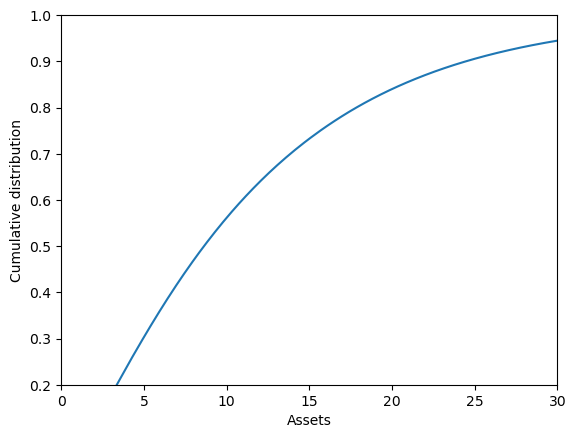

In [120]:
# 5. Create Steady-State Model
ha = sj.create_model([
    hh_extended,
    smart_steady,
    market_clearing,
    steady_auxilliary,
    banker_div,
    sdf,
    government_ss,
    labor_ss,          # calibrates vphi from SS w, N, UCE
], name="Simple HA Model")

# 6. Solve Steady State
unknowns_ss = {'beta': (0.99, 0.993)}
targets_ss  = ['deposit_mkt']

ss = ha.solve_steady_state(
    calibration_start,
    unknowns_ss,
    targets_ss,
    solver='bisect'
)

print(f"beta      = {ss['beta']:.8f}")
print(f"div       = {ss['div']:.6f}   (should ≈ rn*n_inter = {ss['rn']*ss['n_inter']:.6f})")
print(f"goods_mkt = {ss['goods_mkt']:.2e}  (should ≈ 0 by Walras)")
print(f"vphi      = {ss['vphi']:.6f}")

D = ss.internals['hh']['D'].sum(axis=0)
dep_grid = ss.internals['hh']['dep_grid']
plt.plot(dep_grid, D.cumsum())
plt.ylim([0.2, 1])
plt.xlim([0, 30])
plt.xlabel('Assets')
plt.ylabel('Cumulative distribution')
plt.show()

cali = ss
calibration = dict(ss)

#### OFF STEADY-STATE EQUATIONS

In [121]:
# ── Off-Steady-State Equations ────────────────────────────────────────────────

# ==> CAPITAL BLOCK
@simple
def capital_adj(Y, K, Q, I, alpha, delta, gamma0, gamma1, ksi, Z):
    iota        = I / K(-1)
    mpk         = alpha * Y / K(-1)
    rk          = (mpk + (1 - delta) * Q) / Q(-1) - 1
    q_res       = Q - 1 / (gamma0 * (1 - ksi) * iota ** (-ksi))
    capital_res = K - (1 - delta) * K(-1) - (gamma0 * iota ** (1 - ksi) + gamma1) * K(-1)
    return iota, mpk, rk, q_res, capital_res

# ==> LABOUR BLOCK (model_8 style: Y is an unknown, N and w are derived)
@simple
def labor(Y, Z, K, alpha):
    # Invert production function to find N consistent with Y, Z, K(-1)
    N = (Y / (Z * K(-1) ** alpha)) ** (1 / (1 - alpha))
    w = (1 - alpha) * Y / N
    return N, w

@simple
def labor_market(w, UCE, N, vphi, frisch):
    # Labour supply optimality: w = vphi * N^(1/frisch) / UCE
    mrs           = vphi * N ** (1 / frisch) / UCE
    labor_mkt_res = w - mrs
    return labor_mkt_res


# ==> FINANCIAL INTERMEDIATION BLOCK
@simple
def intermediation_IC(nu, eta, lambda_gk):
    theta = eta / (lambda_gk - nu)
    return theta

@simple
def bank_return(theta, rk, rdep, b_gov, n_inter, rb, def_rate, recovery_rate):
    haircut   = 1.0 - recovery_rate
    phi_b_lag = b_gov(-1) / n_inter(-1)
    rb_actual = (1 - def_rate * haircut) * (1 + rb(-1)) - 1

    rn = theta(-1) * (rk - rdep) + phi_b_lag * (rb_actual - rdep) + rdep
    return rn, rb_actual

@simple
def intermediation_P1(rk, rdep, nu, lambda_gk, eta, theta, SDF, f):
    Omega_p1 = f + (1 - f) * lambda_gk * theta(+1)
    nu_res   = nu  - SDF * Omega_p1 * (rk(+1) - rdep(+1))
    eta_res  = eta - SDF * Omega_p1 * (1 + rdep(+1))
    return nu_res, eta_res

@simple
def k_balance_sheet(Q,theta, n_inter, K):
    K_res = Q*K - theta * n_inter
    return K_res

@simple
def intermediation_P2(rn, n_inter, m, f, cap_profit):
    gross_income = (1 + rn) * n_inter(-1) + cap_profit
    n_inter_val = (1 - f) * gross_income + m - n_inter
    return n_inter_val

@simple
def banker_div_res(rn, n_inter, div, m, f, cap_profit):
    gross_income = (1 + rn) * n_inter(-1) + cap_profit
    net_div = f * gross_income - m
    div_res = div - net_div
    return div_res

@simple
def intermediation_P3(Q,K, n_inter, b_gov):
    #D_supply = (theta - 1) * n_inter + b_gov
    D_supply = Q * K + b_gov - n_inter

    return D_supply


# ==> GOVERNMENT AND DEFAULT BLOCK (structure from model_8)
@simple
def interest_rates(def_rate, recovery_rate, SDF):
    haircut = 1 - def_rate(+1) * (1.0 - recovery_rate)
    rb = 1 / (SDF * haircut) - 1
    return rb

@simple
def government_default(shock_def):
    def_rate = shock_def
    return def_rate

@simple
def tax_rule(b_gov, lamb_ss, b_gov_ss, phi_lamb):
    lamb = lamb_ss - phi_lamb * (b_gov(-1) - b_gov_ss)
    return lamb

@simple
def capital_producer_profit(Q, K, I, delta):
    cap_profit = Q * (K - (1 - delta) * K(-1)) - I
    return cap_profit

@simple
def budget_residual(b_gov, G, TAX, rb, def_rate, recovery_rate):
    haircut = 1.0 - recovery_rate
    effective_repayment = (1 - def_rate * haircut) * (1 + rb(-1)) * b_gov(-1)
    b_gov_res = effective_repayment + G - TAX - b_gov
    return b_gov_res


print(calibration)

{'frisch': 1.0, 'eis': 0.5, 'habit': 0.0, 'C_lag': 0.0, 'rdep': 0.0065, 'rb': 0.0065, 'B_supply': 2.4, 'tau': 0.181, 'lamb': 0.85, 'lamb_ss': 0.85, 'phi_lamb': 0.1, 'shock_def': 0.0, 'def_rate': 0.0, 'def_curvature': 0.5, 'recovery_rate': 0.4, 'Y': 1.0, 'N': 1.0, 'w': 0.65, 'f': 0.06, 'lambda_gk': 0.116, 'ksi': 0.5, 'n_inter': 3.0, 'theta': 4, 'alpha': 0.35, 'delta': 0.0125, 'nZ': 19, 'nDep': 500, 'Depmax': 150, 'rho_z': 0.9, 'sigma_z': 0.5, 'Q': 1.0, 'b_gov': 2.4, 'b_gov_ss': 2.4, 'beta': 0.9923892785038333, 'K': 12.0, 'rk': 0.016666666666666663, 'rn': 0.047166666666666655, 'm': 0.04699000000000042, 'k_inter': 12.0, 'I': 0.15000000000000002, 'D_supply': 11.4, 'Z': 0.4190699921000142, 'rdep_ante': 0.0065, 'cap_profit': -1.4432899320127035e-15, 'div': 0.14149999999999996, 'iota': 0.0125, 'mpk': 0.029166666666666664, 'Omega': 0.4464986062717814, 'nu': 0.0045048543689320385, 'eta': 0.44598058252427186, 'gamma0': 0.22360679774997896, 'gamma1': -0.0125, 'DEP': np.float64(11.400000003221638)

#### FULL MODEL

In [122]:
# Solve for forward-looking IC multipliers internally
financial_solved = combine([
    sdf,
    intermediation_IC,
    intermediation_P1,
]).solved(
    unknowns={
        'nu':  float(cali['nu']),
        'eta': float(cali['eta']),
    },
    targets=['nu_res', 'eta_res'],
    solver='broyden_custom'
)

print("financial_solved inputs: ", financial_solved.inputs)
print("financial_solved outputs:", financial_solved.outputs)


ha_full = sj.create_model([
    hh_extended,
    financial_solved,       # theta, nu, eta from IC + Bellman
    interest_rates,         # rb: no-arbitrage against expected default
    government_default,     # def_rate from shock_def
    bank_return,            # rn, rb_actual: bankers bear sovereign haircut
    intermediation_P2,      # n_inter_val: banker net worth accumulation
    intermediation_P3,      # D_supply: deposit supply (uses dynamic b_gov)
    k_balance_sheet,        # K_res
    capital_adj,            # rk, q_res, capital_res
    tax_rule,               # lamb: transfer rule stabilises debt
    capital_producer_profit,
    budget_residual,        # b_gov_res: govt budget with haircut
    labor,                  # N, w: invert production (Y is unknown)
    labor_market,           # labor_mkt_res: w = MRS closes labour market
    banker_div_res,         # div_res
    market_clearing,        # goods_mkt, deposit_mkt
], name="Full HANK Model")

# 8 unknowns — 8 targets (square system)
unknowns_tp = ['rdep', 'K', 'n_inter', 'div', 'I', 'Q', 'b_gov', 'Y']
targets_tp  = ['deposit_mkt', 'K_res', 'n_inter_val', 'div_res',
               'capital_res', 'q_res', 'b_gov_res', 'labor_mkt_res']

T = 300
exogenous = ['Z', 'shock_def']

print(f"Computing Jacobian for horizon T={T}...")
G_jac = ha_full.solve_jacobian(ss, unknowns_tp, targets_tp, exogenous, T=T)
print("Jacobian computed successfully.")

financial_solved inputs:  ['beta', 'UCE', 'lambda_gk', 'rk', 'rdep', 'f']
financial_solved outputs: ['SDF', 'theta', 'nu_res', 'eta_res', 'eta', 'nu']
Computing Jacobian for horizon T=300...
Jacobian computed successfully.


### IMPULSE RESPONSE FUNCTIONS

In [123]:
def show_irfs(irfs_list, variables, labels=[" "], ylabel=r"Percentage points (dev. from ss)", T_plot=50, figsize=(18, 6)):
    if len(irfs_list) != len(labels):
        labels = [" "] * len(irfs_list)
    n_var = len(variables)
    fig, ax = plt.subplots(1, n_var, figsize=figsize, sharex=True)
    for i in range(n_var):
        for j, irf in enumerate(irfs_list):
            ax[i].plot(irf[variables[i]][:T_plot], label=labels[j])
        ax[i].set_title(variables[i])
        ax[i].set_xlabel(r"$t$")
        if i == 0:
            ax[i].set_ylabel(ylabel)
        ax[i].legend()
    plt.show()

In [124]:
# ── Impulse Response Functions ───────────────────────────────────────

# TFP Shock
rho_Z = 0.8
dZ    = 0.01 * rho_Z ** np.arange(T)

print("Computing IRF: TFP shock...")
irfs_Z = ha_full.solve_impulse_linear(ss, unknowns_tp, targets_tp, {'Z': dZ})

# Default Shock
rho_def    = 0.8
dShock_def = 0.01 * rho_def ** np.arange(T)

print("Computing IRF: default shock...")
irfs_def = ha_full.solve_impulse_linear(ss, unknowns_tp, targets_tp, {'shock_def': dShock_def})

Computing IRF: TFP shock...
Computing IRF: default shock...


In [125]:
real = ['Z', 'shock_def', 'def_rate', 'Y', 'C', 'I', 'K', 'Q', 'N', 'w', 'iota', 'mpk', 'cap_profit']

financial = [
    'theta', 'n_inter', 'rn', 'nu', 'eta',
    'rdep', 'rb', 'rb_actual',
    'b_gov', 'DEP', 'D_supply'
]

gov = ['def_rate', 'shock_def', 'b_gov', 'rb', 'rb_actual', 'TAX', 'lamb', 'G']

residuals = [
    'goods_mkt', 'deposit_mkt', 'K_res', 'n_inter_val',
    'div_res', 'capital_res', 'q_res', 'b_gov_res',
    'labor_mkt_res', 'nu_res', 'eta_res'
]

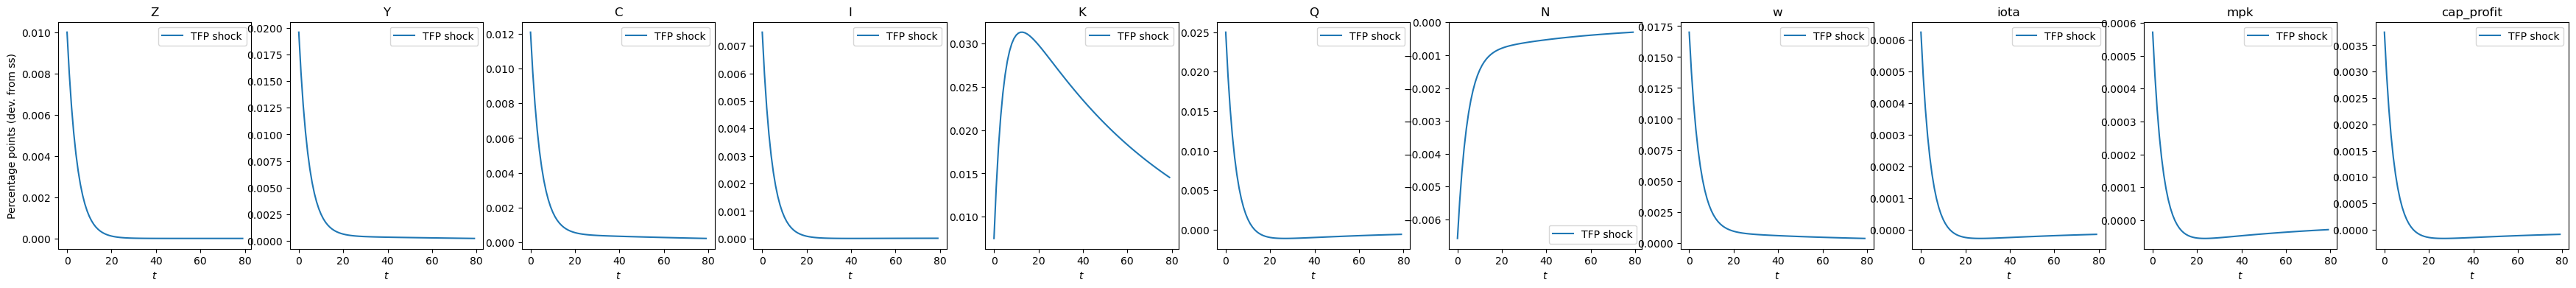

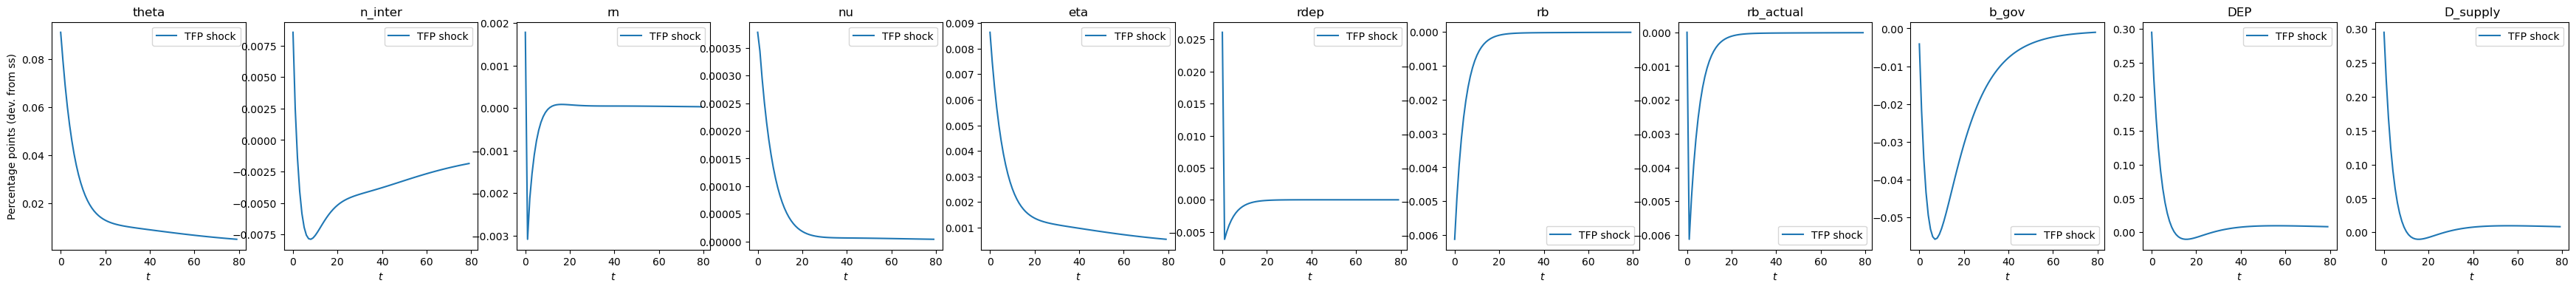

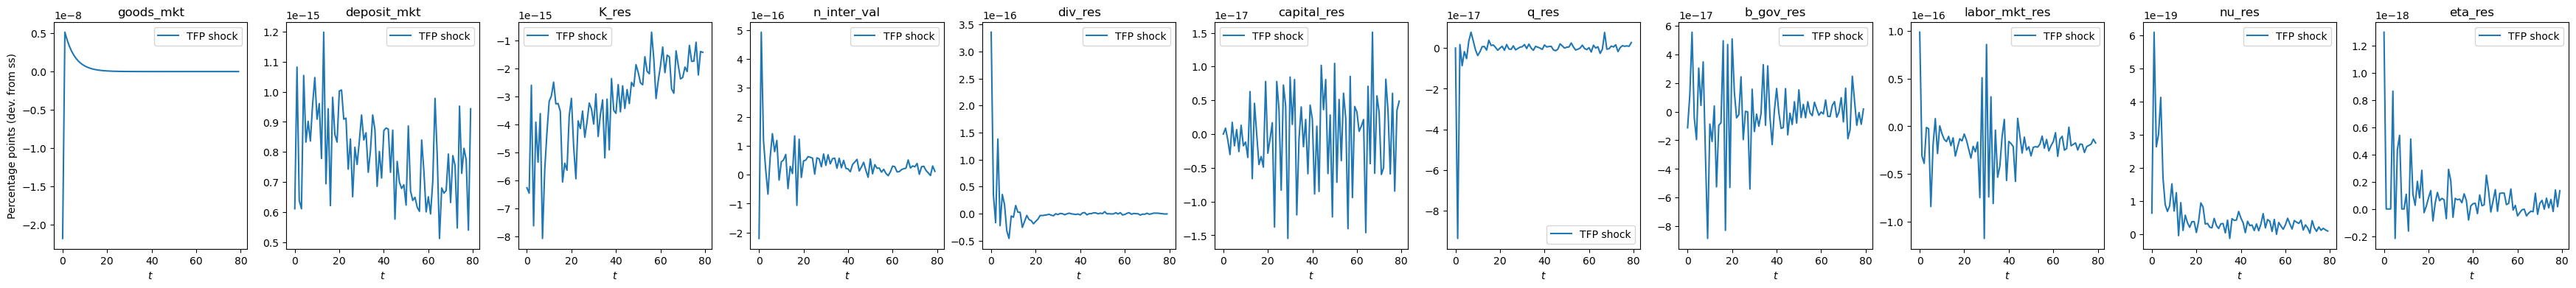

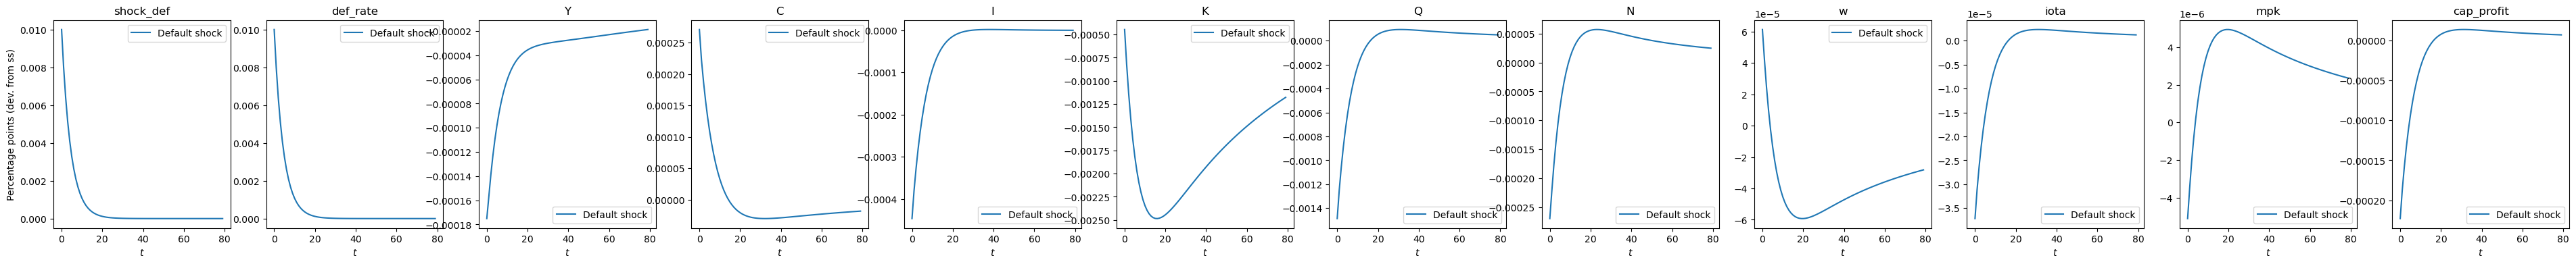

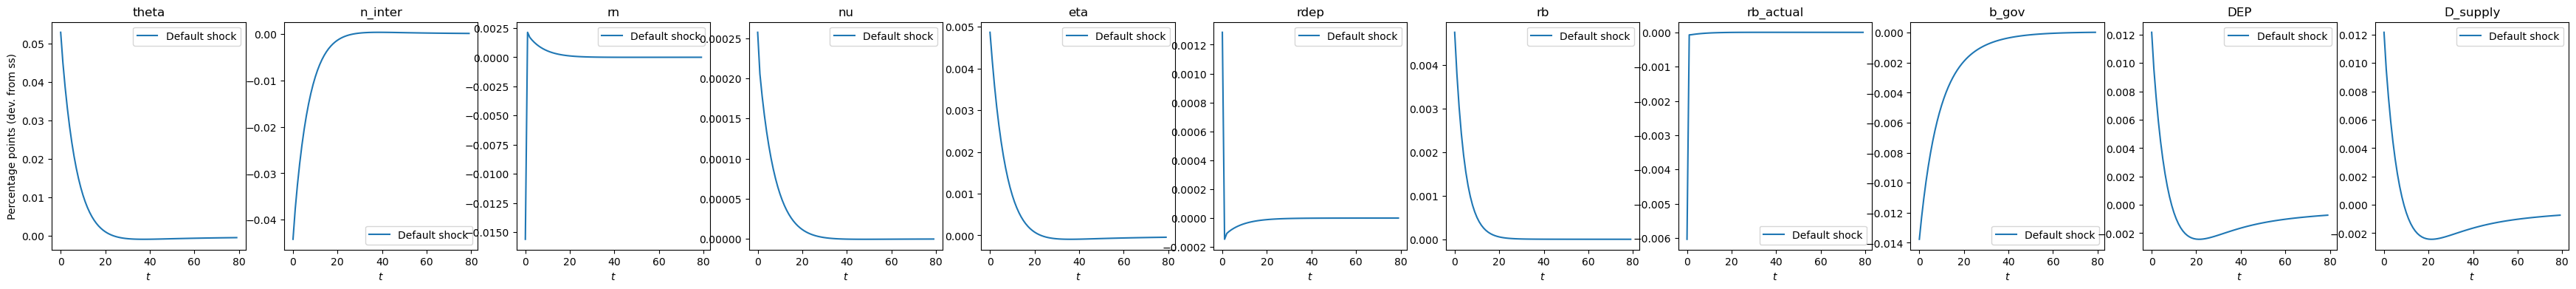

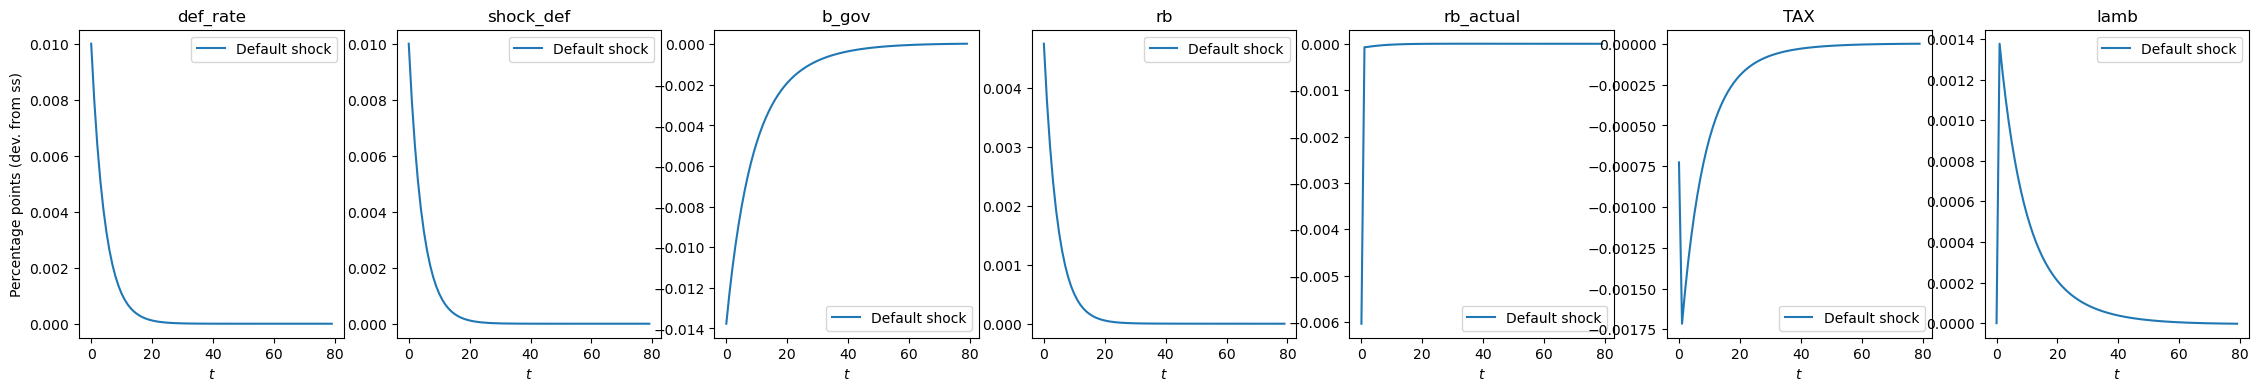

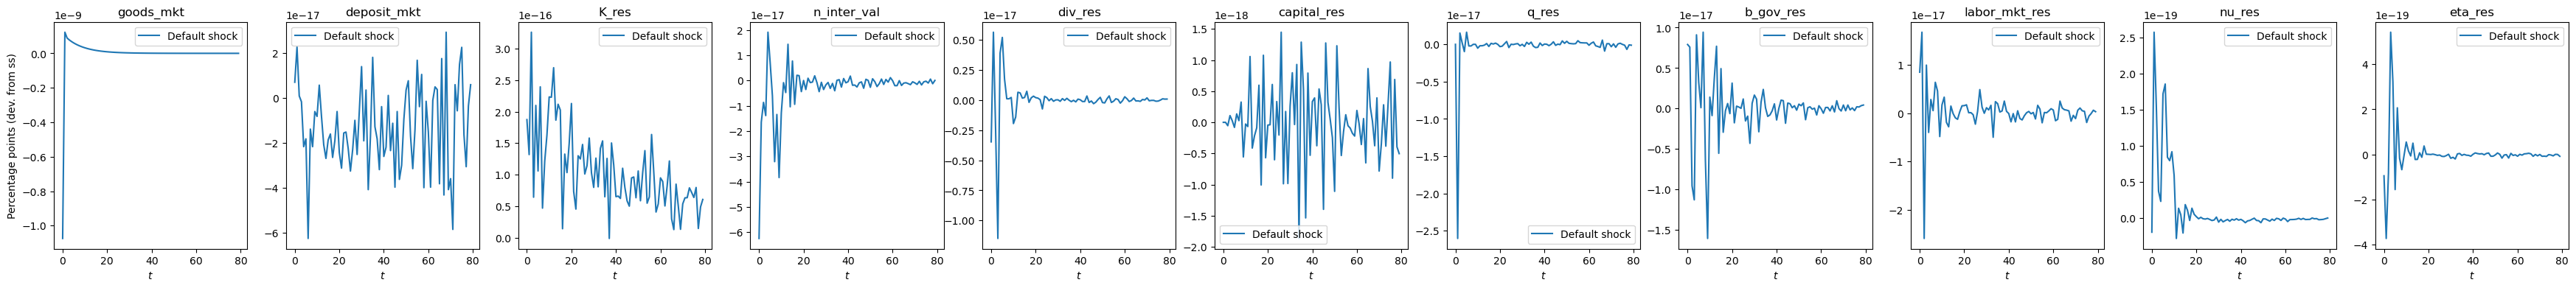

In [126]:
show(irfs_Z, real, 'TFP shock')
show(irfs_Z, financial, 'TFP shock')
show(irfs_Z, residuals, 'TFP shock')

show(irfs_def, real, 'Default shock')
show(irfs_def, financial, 'Default shock')
show(irfs_def, gov, 'Default shock')
show(irfs_def, residuals, 'Default shock')